In [ ]:
import string
import re

import pandas as pd
import numpy as np
import py_stringmatching as sm

from copy import deepcopy


<a id="schema-matching-con-value-overlap"></a>
# Schema Matching con Value Overlap

In questo notebook vogliamo approfondire il metodo di schema matching basato su Value Overlap, introducendo un modo più efficiente per effettuarlo, basato sulla nozione 
di **set similarity join** (o **string similarity join**) 

In questo modo, anche in caso di  dataset "reali" quali ad esempio

TableA = pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/imdb.csv')

TableB = pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/784_data/movies1/csv_files/rotten_tomatoes.csv')

è possibile ottenere il seguente risultato di schema matching basato su Value Overlap:

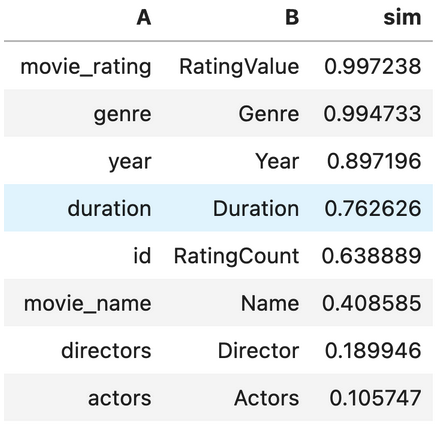

Dopo la sezione preliminare che richiama le funzioni già introdotte,
nella sezione **Label-based similarity**  si considerano altre funzioni oltre alla *Levenshtein*.

Si introduce quindi il **Value Overlap: Jaccard**  ed il **Value Overlap: Extended Jaccard**, mostrando come queste operazioni equivalgono rispettivamente al Join (merge) 
classico/esatto ed ad un Join *approssimato* denominato **Similarity Join**.  Infine il concetto di **Set Similarity Join**

<a id="schema-matching"></a>
# Schema Matching

<a id="to-sim-table-e-to-sim-matrix"></a>
## to_sim_table e to_sim_matrix

In [4]:
def sim_table(TableA:pd.DataFrame, TableB:pd.DataFrame):
    A = pd.DataFrame({"A": TableA.columns})
    B = pd.DataFrame({"B": TableB.columns})
    S = A.assign(key=1).merge(B.assign(key=1), on="key").drop("key", axis=1)
#    S = A.merge(B, how='cross') non funziona con le vecchie versioni
    return S

def random_sim_table(TableA:pd.DataFrame, TableB:pd.DataFrame):
    S = sim_table(TableA, TableB)
    S["sim"] = np.random.rand(len(S))
    return S

def to_sim_table(SimMatrix:pd.DataFrame):
    return SimMatrix.stack().reset_index(name="sim")

def to_sim_matrix(SimTable:pd.DataFrame):
    return SimTable.pivot(index="A", columns="B", values="sim") \
              .rename_axis(None, axis=1).rename_axis(None, axis=0)

def string_preprocess(s:str, char:str=string.punctuation, word:list=[]):
    if type(s) is str:
        s = s.lower()
        for c in char:
            s = s.replace(c, " ")
        for w in word:
            s = s.replace(w, " ")
    else:
        s = str(s)
    s = re.sub(" +", " ", s)
    return s.strip()

In [5]:
# Esempio
SchemaA=['ID', 'Name', 'Vorname', 'Alter']
SchemaB=['No', 'Name', 'First_name', 'Age']
#
TableA = pd.DataFrame(columns=SchemaA)
TableB = pd.DataFrame(columns=SchemaB)

SimTable=sim_table(TableA,TableB)
SimTable

,A,B
0,ID,No
1,ID,Name
2,ID,First_name
3,ID,Age
4,Name,No
5,Name,Name
6,Name,First_name
7,Name,Age
8,Vorname,No
9,Vorname,Name


In [6]:
# Esempio
SchemaA=['ID', 'Name', 'Vorname', 'Alter']
SchemaB=['No', 'Name', 'First_name', 'Age']
#
TableA = pd.DataFrame(columns=SchemaA)
TableB = pd.DataFrame(columns=SchemaB)

SimTable=random_sim_table(TableA,TableB)
SimTable

,A,B,sim
0,ID,No,0.788898
1,ID,Name,0.317586
2,ID,First_name,0.651948
3,ID,Age,0.531414
4,Name,No,0.352428
5,Name,Name,0.939563
6,Name,First_name,0.656681
7,Name,Age,0.488366
8,Vorname,No,0.026974
9,Vorname,Name,0.262499


In [7]:
SimMatrix=to_sim_matrix(SimTable)
SimMatrix

,Age,First_name,Name,No
Alter,0.430573,0.130078,0.062291,0.294505
ID,0.531414,0.651948,0.317586,0.788898
Name,0.488366,0.656681,0.939563,0.352428
Vorname,0.438074,0.033226,0.262499,0.026974


<a id="labed-based-similarity"></a>
# Labed-based similarity

In [8]:
def levenshtein_sim(row:pd.Series):
    lev = sm.Levenshtein()
    return lev.get_sim_score(
            string_preprocess(row["A"]),
            string_preprocess(row["B"])
        )

def levenshtein_label_based_similarity(TableA:pd.DataFrame, TableB:pd.DataFrame):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(levenshtein_sim, axis=1)
    return C.sort_values("sim", ascending=False)

In [9]:
levenshtein_label_based_similarity(TableA,TableB)
to_sim_matrix(levenshtein_label_based_similarity(TableA,TableB))

,Age,First_name,Name,No
Alter,0.400000,0.1,0.200000,0.000000
ID,0.000000,0.1,0.000000,0.000000
Name,0.500000,0.4,1.000000,0.250000
Vorname,0.285714,0.5,0.571429,0.142857


In [10]:
# Nota
def levenshtein_sim(row:pd.Series):
    lev = sm.Levenshtein()
    return lev.get_sim_score(
            string_preprocess(row["A"]),
            string_preprocess(row["B"])
        )
# row è una serie che rappresenta un record della SimTable le cui colonne le abbiamo chimate A e B
row = pd.Series({'A': 'casa', 'B': 'cava'})
levenshtein_sim(row)

0.75

La stessa cosa si può fare per altre funzioni di similarità

In [11]:
# Jaccard
def jaccard_sim(row:pd.Series):
    jac=sm.Jaccard()
    tok = sm.WhitespaceTokenizer(return_set=True)
    return jac.get_sim_score(
            tok.tokenize(string_preprocess(row["A"])),
            tok.tokenize(string_preprocess(row["B"]))
    )

def jaccard_label_based_similarity(TableA:pd.DataFrame, TableB:pd.DataFrame):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(jaccard_sim, axis=1)
    return C.sort_values("sim", ascending=False)

# OverlapCoefficient
def OC_sim(row:pd.Series):
    oc = sm.OverlapCoefficient()
    tok = sm.WhitespaceTokenizer(return_set=True)
    return oc.get_sim_score(
            tok.tokenize(string_preprocess(row["A"])),
            tok.tokenize(string_preprocess(row["B"]))
    )

def OC_label_based_similarity(TableA:pd.DataFrame, TableB:pd.DataFrame):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(OC_sim, axis=1)
    return C.sort_values("sim", ascending=False)

# JaroWinkler
def JaroWinkler_sim(row:pd.Series):
    jw = sm.JaroWinkler()
    return jw.get_sim_score(
            string_preprocess(row["A"]),
            string_preprocess(row["B"])
        )

def JaroWinkler_label_based_similarity(TableA:pd.DataFrame, TableB:pd.DataFrame):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(JaroWinkler_sim, axis=1)
    return C.sort_values("sim", ascending=False)

# MongeElkan
#Secondary similarity function. This is expected to be a sequence-based similarity measure 
#(defaults to Jaro-Winkler similarity measure).
def MongeElkan_sim(row:pd.Series):
    me = sm.MongeElkan()
    tok = sm.WhitespaceTokenizer(return_set=True)
    return me.get_raw_score(
            tok.tokenize(string_preprocess(row["A"])),
            tok.tokenize(string_preprocess(row["B"]))
    )


def MongeElkan_label_based_similarity(TableA:pd.DataFrame, TableB:pd.DataFrame):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(MongeElkan_sim, axis=1)
    return C.sort_values("sim", ascending=False)

In [12]:
### meglio riportare le funzioni di similarità definite all’interno delle rispettive funzioni 

# Jaccard
def jaccard_label_based_similarity(TableA: pd.DataFrame, TableB: pd.DataFrame):
    def jaccard_sim(row: pd.Series):
        jac = sm.Jaccard()
        tok = sm.WhitespaceTokenizer(return_set=True)
        return jac.get_sim_score(
            tok.tokenize(string_preprocess(row["A"])),
            tok.tokenize(string_preprocess(row["B"]))
        )
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(jaccard_sim, axis=1)
    return C.sort_values("sim", ascending=False)

# Overlap Coefficient
def OC_label_based_similarity(TableA: pd.DataFrame, TableB: pd.DataFrame):
    def OC_sim(row: pd.Series):
        oc = sm.OverlapCoefficient()
        tok = sm.WhitespaceTokenizer(return_set=True)
        return oc.get_sim_score(
            tok.tokenize(string_preprocess(row["A"])),
            tok.tokenize(string_preprocess(row["B"]))
        )
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(OC_sim, axis=1)
    return C.sort_values("sim", ascending=False)

# Jaro-Winkler
def JaroWinkler_label_based_similarity(TableA: pd.DataFrame, TableB: pd.DataFrame):
    def JaroWinkler_sim(row: pd.Series):
        jw = sm.JaroWinkler()
        return jw.get_sim_score(
            string_preprocess(row["A"]),
            string_preprocess(row["B"])
        )
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(JaroWinkler_sim, axis=1)
    return C.sort_values("sim", ascending=False)

# Monge-Elkan
def MongeElkan_label_based_similarity(TableA: pd.DataFrame, TableB: pd.DataFrame):
    def MongeElkan_sim(row: pd.Series):
        me = sm.MongeElkan()
        tok = sm.WhitespaceTokenizer(return_set=True)
        return me.get_raw_score(
            tok.tokenize(string_preprocess(row["A"])),
            tok.tokenize(string_preprocess(row["B"]))
        )
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(MongeElkan_sim, axis=1)
    return C.sort_values("sim", ascending=False)

In [13]:
# Confrontiamole in questo semplice esempio
SchemaA=['Nome_Cognome', 'Nome_Cognome (Nominativo)']
SchemaB=['Cognome_Nome','Cognom_Nom']

TableA = pd.DataFrame(columns=SchemaA)
TableB = pd.DataFrame(columns=SchemaB)
LEV = levenshtein_label_based_similarity(TableA, TableB)
JAC = jaccard_label_based_similarity(TableA, TableB)
OC = OC_label_based_similarity(TableA, TableB)
JW = JaroWinkler_label_based_similarity(TableA, TableB)
ME = MongeElkan_label_based_similarity(TableA, TableB)
LEV.merge(JAC, on=['A','B'], suffixes=('', '_JAC')) \
   .merge(OC, on=['A','B'], suffixes=('', '_OC')).merge(JW, on=['A','B'], suffixes=('', '_JW')) \
   .merge(ME, on=['A','B'], suffixes=('_LEV', '_ME'))

,A,B,sim_LEV,sim_JAC,sim_OC,sim_JW,sim_ME
0,Nome_Cognome,Cognome_Nome,0.500000,1.000000,1.0,0.916667,1.000000
1,Nome_Cognome (Nominativo),Cognome_Nome,0.478261,0.666667,1.0,0.757246,0.926111
2,Nome_Cognome (Nominativo),Cognom_Nom,0.434783,0.000000,0.0,0.711594,0.916587
3,Nome_Cognome,Cognom_Nom,0.333333,0.000000,0.0,0.844444,0.956548


<a id="value-overlap-jaccard"></a>
# Value Overlap:    Jaccard

Consideriamo la definizione della Value Overlap basata sulla Jaccard *semplice*
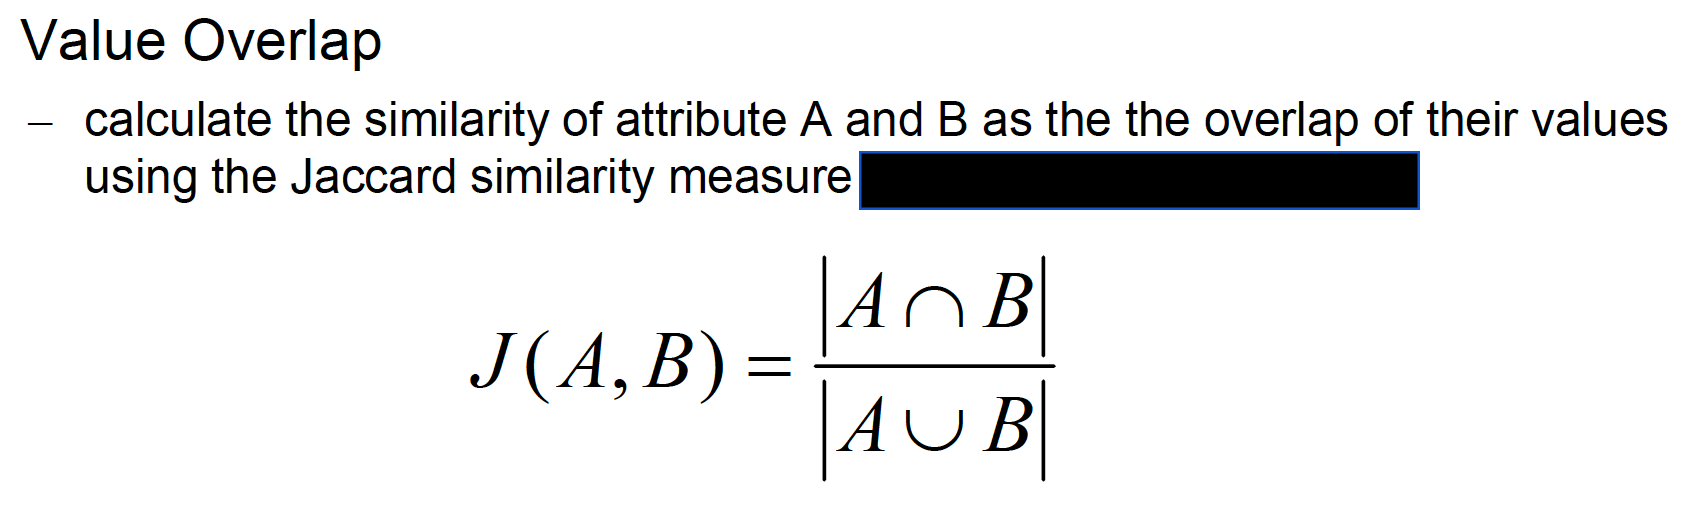


In [30]:
#
# 
TableA = pd.DataFrame({  'AX':  ['prof rossi ugo', 'rossi ugo ing prof', 'verde ugo']})
TableB = pd.DataFrame({ 'AY':   [ 'luigi rossi prof', 'verde ugo', 'ugo rossi ing']})

In [31]:
TableB

,AY
0,luigi rossi prof
1,verde ugo
2,ugo rossi ing


In [32]:
# se X è un attributo di TableA
X='AX'
TableA[X].apply(string_preprocess).tolist()

['prof rossi ugo', 'rossi ugo ing prof', 'verde ugo']

In [33]:
X='AY'
TableB[X].apply(string_preprocess).tolist()

['luigi rossi prof', 'verde ugo', 'ugo rossi ing']

In [34]:
def jaccard_sim(row:pd.Series, TableA:pd.DataFrame,TableB:pd.DataFrame):
    j = sm.Jaccard()
    return j.get_raw_score(
            TableA[row["A"]].apply(string_preprocess).tolist(),
            TableB[row["B"]].apply(string_preprocess).tolist()
        )
# row è una serie che rappresenta un record della SimTable le cui colonne le abbiamo chimate A e B

row = pd.Series({'A': 'AX', 'B': 'AY'})

jaccard_sim(row, TableA, TableB)

0.2

In [35]:
C = sim_table(TableA, TableB)
C

,A,B
0,AX,AY


In [36]:
C["sim"] = C.apply(jaccard_sim, args=(TableA, TableB), axis=1)
C

,A,B,sim
0,AX,AY,0.2


In [38]:
def jaccard_sim(row:pd.Series, TableA:pd.DataFrame,TableB:pd.DataFrame):
    j = sm.Jaccard()
    return j.get_raw_score(
            TableA[row["A"]].apply(string_preprocess).tolist(),
            TableB[row["B"]].apply(string_preprocess).tolist()
        )

def jaccard_value_overlap_sim(TableA:pd.DataFrame, TableB:pd.DataFrame):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(jaccard_sim, args=(TableA, TableB), axis=1)
    return C.sort_values("sim", ascending=False)

In [39]:
def jaccard_value_overlap_sim(TableA: pd.DataFrame, TableB: pd.DataFrame):
    def jaccard_sim(row: pd.Series):
        j = sm.Jaccard()
        return j.get_raw_score(
            TableA[row["A"]].apply(string_preprocess).tolist(),
            TableB[row["B"]].apply(string_preprocess).tolist()
        )
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(jaccard_sim, axis=1)
    return C.sort_values("sim", ascending=False)

In [40]:
jaccard_value_overlap_sim(TableA,TableB)

,A,B,sim
0,AX,AY,0.2


In [43]:
TableA= pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/imdb.csv').astype(str)
TableB= pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/roger_ebert.csv').astype(str)

jaccard_value_overlap_sim(TableA,TableB)

,A,B,sim
0,id,id,0.514393
50,movie_rating,critic_rating,0.074074
30,directors,directors,0.068378
60,genre,genre,0.046512
10,movie_name,movie_name,0.038788
...,...,...,...
32,directors,critic_rating,0.000000
33,directors,genre,0.000000
34,directors,pg_rating,0.000000
35,directors,duration,0.000000


In [42]:
TableA

,id,movie_name,year,directors,actors,movie_rating,genre,duration
0,0,High-Rise,2015,Ben Wheatley,"Tom Hiddleston, Jeremy Irons, Sienna Miller",6.8,"Action, Drama, Sci-Fi",112 min
1,1,Mercy for Angels,2015,K.C. Amos,"Vida Guerra, Emilio Rivera, John Amos",6.2,"Action, Drama, Thriller",91 min
2,2,Wind Walkers,2015,Russell Friedenberg,"Glen Powell, Zane Holtz, Rudy Youngblood",5.6,"Action, Horror, Thriller",93 min
3,3,Alcatraz Prison Escape: Deathbed Confession,2015,John Edward Lee,"Danny Trejo, Ed O'Ross, Shelby Deekins",6.6,"Action, Crime",93 min
4,4,Barely Lethal,2015,Kyle Newman,"Jaime King, Samuel L. Jackson, Madeleine Stack",5.3,"Action, Adventure, Comedy",96 min
...,...,...,...,...,...,...,...,...
6908,6908,When the Clouds Roll by,1919,Victor Fleming,"Douglas Fairbanks, Albert MacQuarrie, Kathleen...",7.0,"Action, Comedy, Romance",85 min
6909,6909,Tarzan of the Apes,1918,Scott Sidney,"Elmo Lincoln, Enid Markey, True Boardman",6.0,"Action, Adventure",73 min
6910,6910,The Life of General Villa,1914,Christy Cabanne,"Eagle Eye, Robert Harron, Irene Hunt",6.7,"Action, Adventure, Biography",105 min
6911,6911,The Perils of Pauline,1914,Louis J. Gasnier,"Pearl White, Crane Wilbur, Paul Panzer",7.6,Action,199 min


<a id="calcolo-tramite-join-merge"></a>
## Calcolo tramite Join (merge)
Per mostrare che è possibile fare lo stesso calcolo tramite Join:

In [44]:
TableA = pd.DataFrame({  'AX':  ['prof rossi ugo', 'rossi ugo ing prof', 'verde ugo']})
TableB = pd.DataFrame({ 'AY':   [ 'luigi rossi prof', 'verde ugo', 'ugo rossi ing']})
# 1. Calcolo di tutte le coppie di valori:  prodotto cartesiano 
PCC = TableA.drop_duplicates().assign(key=1).merge(TableB.drop_duplicates().assign(key=1), on="key").drop("key", axis=1)
#PCC = TableA.drop_duplicates().merge(TableB.drop_duplicates(), how='cross')
# si tolgono eventuali duplicati perchè non vogliamo considerarli nel calcolo della Value Overlap
PCC

,AX,AY
0,prof rossi ugo,luigi rossi prof
1,prof rossi ugo,verde ugo
2,prof rossi ugo,ugo rossi ing
3,rossi ugo ing prof,luigi rossi prof
4,rossi ugo ing prof,verde ugo
5,rossi ugo ing prof,ugo rossi ing
6,verde ugo,luigi rossi prof
7,verde ugo,verde ugo
8,verde ugo,ugo rossi ing


In [45]:
# 2. con la Jaccard semplice l'intersezione viene fatta tramite join esatto, quindi:
INTERSEZIONE =  PCC[PCC.AX==PCC.AY].drop_duplicates() # JOIN ESATTO
INTERSEZIONE

,AX,AY
7,verde ugo,verde ugo


In [46]:
SoloInAX=PCC.loc[~PCC['AX'].isin(INTERSEZIONE['AX'])][['AX']].drop_duplicates()
SoloInAX

,AX
0,prof rossi ugo
3,rossi ugo ing prof


In [47]:
SoloInAY=PCC.loc[~PCC['AY'].isin(INTERSEZIONE['AY'])][['AY']].drop_duplicates()
SoloInAY

,AY
0,luigi rossi prof
2,ugo rossi ing


In [48]:
# 3. la cardinalità di A UNION B  si può calcolare  dalla cardinalità dell'INTERSEZIONE, len(INTERSEZIONE), - come segue
SoloInAX=PCC.loc[~PCC['AX'].isin(INTERSEZIONE['AX'])][['AX']].drop_duplicates()
SoloInAY=PCC.loc[~PCC['AY'].isin(INTERSEZIONE['AY'])][['AY']].drop_duplicates()
print(len(SoloInAX)+len(SoloInAY)+len(INTERSEZIONE))
# e quindi la Value Overlap calcolata con la Jaccard semplice risulta essere
len(INTERSEZIONE)/(len(SoloInAX)+len(SoloInAY)+len(INTERSEZIONE))

5


0.2

<a id="value-overlap-extended-jaccard"></a>
# Value Overlap: Extended Jaccard
Nella Extended Jaccard si considera la similità di ogni coppia del prodotto cartesiano \
calcolata  tramite una  funzione di similarità *interna*; ad esempio la classica Levenshtein

In [50]:
def funzione_similarita_interna(row:pd.Series):
    lev = sm.Levenshtein()
    return lev.get_sim_score(
            string_preprocess(row["AX"]),
            string_preprocess(row["AY"])        )
PCC = TableA.drop_duplicates().assign(key=1).merge(TableB.drop_duplicates().assign(key=1), on="key").drop("key", axis=1)
#PCC = TableA.drop_duplicates().merge(TableB.drop_duplicates(), how='cross')
PCC["sim"] = PCC.apply(funzione_similarita_interna, axis=1)
PCC

,AX,AY,sim
0,prof rossi ugo,luigi rossi prof,0.500000
1,prof rossi ugo,verde ugo,0.357143
2,prof rossi ugo,ugo rossi ing,0.571429
3,rossi ugo ing prof,luigi rossi prof,0.444444
4,rossi ugo ing prof,verde ugo,0.222222
5,rossi ugo ing prof,ugo rossi ing,0.277778
6,verde ugo,luigi rossi prof,0.187500
7,verde ugo,verde ugo,1.000000
8,verde ugo,ugo rossi ing,0.153846


In [51]:
#   **Value Overlap** considerando le coppie come sovrapposte (e quindi in INTERSEZIONE) 
#    solo se la loro similarità supera una certa soglia.
#    è una semplice selezione delle righe di PCC
INTERSEZIONE =  PCC[PCC.sim>=0.45]
INTERSEZIONE

,AX,AY,sim
0,prof rossi ugo,luigi rossi prof,0.500000
2,prof rossi ugo,ugo rossi ing,0.571429
7,verde ugo,verde ugo,1.000000


In [52]:
#  stessa "formula" applicata in precedenza per il calcolo della Value Overlap
SoloInAX=PCC.loc[~PCC['AX'].isin(INTERSEZIONE['AX'])][['AX']].drop_duplicates()
SoloInAY=PCC.loc[~PCC['AY'].isin(INTERSEZIONE['AY'])][['AY']].drop_duplicates()
len(INTERSEZIONE)/(len(SoloInAX)+len(SoloInAY)+len(INTERSEZIONE))

0.75

In [53]:
def funzione_similarita_internaLEV(row:pd.Series): # Levenshtein
    lev = sm.Levenshtein()
    return lev.get_sim_score(
            string_preprocess(row["AX"]),
            string_preprocess(row["AY"])
        )

def extended_value_overlap_sim_LEV(row:pd.Series, TableA:pd.DataFrame,TableB:pd.DataFrame, threshold:float):
    TX = TableA[[row["A"]]].applymap(string_preprocess).drop_duplicates()
    TY = TableB[[row["B"]]].applymap(string_preprocess).drop_duplicates()
    TX.columns=['AX']
    TY.columns=['AY']
    PCC = TX.drop_duplicates().assign(key=1).merge(TY.drop_duplicates().assign(key=1), on="key").drop("key", axis=1)
#    PCC = TX.drop_duplicates().merge(TY.drop_duplicates(), how='cross')
    PCC["SimJac"] = PCC.apply(funzione_similarita_internaLEV, axis=1)
    INTERSEZIONE =  PCC[PCC.SimJac>=threshold]
    SoloInAX=PCC.loc[~PCC['AX'].isin(INTERSEZIONE['AX'])][['AX']].drop_duplicates()
    SoloInAY=PCC.loc[~PCC['AY'].isin(INTERSEZIONE['AY'])][['AY']].drop_duplicates()
    return len(INTERSEZIONE)/(len(SoloInAX)+len(SoloInAY)+len(INTERSEZIONE))

def value_overlap_extended_jaccard_LEV(TableA:pd.DataFrame, TableB:pd.DataFrame, threshold:float):
    C = sim_table(TableA, TableB)
    C["sim_ext_LEV"] = C.apply(extended_value_overlap_sim_LEV, args=(TableA, TableB, threshold), axis=1)
    return C.sort_values("sim_ext_LEV",ascending=False)

In [54]:
value_overlap_extended_jaccard_LEV(TableA,TableB,0.45)

,A,B,sim_ext_LEV
0,AX,AY,0.75


<a id="extendended-jaccard-con-funzione-interna-jaccard"></a>
## Extendended Jaccard, con funzione interna Jaccard 

Finora abbiamo usato come  funzione di similarità *interna* una funzione di tipo *edit-based*, la classica Levenshtein similarity.

Si possono usare  anche funzioni di similarity di tipo *token-based* come la *Jaccard similarity* 

In [55]:
# Definiamo la funzione interna tramite Jaccard con WhitespaceTokenizer
def funzione_similarita_interna(row:pd.Series):
    jac=sm.Jaccard()
    tok = sm.WhitespaceTokenizer(return_set=True)
    return jac.get_sim_score(
            tok.tokenize(string_preprocess(row["AX"])),
            tok.tokenize(string_preprocess(row["AY"])))

PCC = TableA.drop_duplicates().assign(key=1).merge(TableB.drop_duplicates().assign(key=1), on="key").drop("key", axis=1)
#PCC = TableA.drop_duplicates().merge(TableB.drop_duplicates(), how='cross')
PCC["sim_ext_JAC"] = PCC.apply(funzione_similarita_interna, axis=1)
PCC.head()

,AX,AY,sim_ext_JAC
0,prof rossi ugo,luigi rossi prof,0.50
1,prof rossi ugo,verde ugo,0.25
2,prof rossi ugo,ugo rossi ing,0.50
3,rossi ugo ing prof,luigi rossi prof,0.40
4,rossi ugo ing prof,verde ugo,0.20


In [56]:
def funzione_similarita_internaJaccard(row:pd.Series): # Jaccard
    jac=sm.Jaccard()
    tok = sm.WhitespaceTokenizer(return_set=True)
    return jac.get_sim_score(
            tok.tokenize(string_preprocess(row["AX"])),
            tok.tokenize(string_preprocess(row["AY"])))

def extended_value_overlap_sim_JAC(row:pd.Series, TableA:pd.DataFrame,TableB:pd.DataFrame, threshold:float):
    TX = TableA[[row["A"]]].applymap(string_preprocess).drop_duplicates()
    TY = TableB[[row["B"]]].applymap(string_preprocess).drop_duplicates()
    TX.columns=['AX']
    TY.columns=['AY']
    PCC = TX.drop_duplicates().assign(key=1).merge(TY.drop_duplicates().assign(key=1), on="key").drop("key", axis=1)
#    PCC = TX.drop_duplicates().merge(TY.drop_duplicates(), how='cross')
    PCC["SimJac"] = PCC.apply(funzione_similarita_internaJaccard, axis=1)
    INTERSEZIONE =  PCC[PCC.SimJac>=threshold]
    SoloInAX=PCC.loc[~PCC['AX'].isin(INTERSEZIONE['AX'])][['AX']].drop_duplicates()
    SoloInAY=PCC.loc[~PCC['AY'].isin(INTERSEZIONE['AY'])][['AY']].drop_duplicates()
    return len(INTERSEZIONE)/(len(SoloInAX)+len(SoloInAY)+len(INTERSEZIONE))

def value_overlap_extended_jaccard_JAC(TableA:pd.DataFrame, TableB:pd.DataFrame, threshold:float):
    C = sim_table(TableA, TableB)
    C["sim_ext_JAC"] = C.apply(extended_value_overlap_sim_JAC, args=(TableA, TableB, threshold), axis=1)
    return C.sort_values("sim_ext_JAC",ascending=False)

In [63]:
value_overlap_extended_jaccard_JAC(TableA,TableB,0.45)

,A,B,sim_ext_JAC
0,A1,B1,1.0
1,A1,B2,0.6
2,A1,B3,0.6
3,A2,B1,0.5
4,A2,B2,0.2
5,A2,B3,0.2


In [65]:
TableA= pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/imdb.csv').astype(str)
TableB= pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/roger_ebert.csv').astype(str)



In [66]:
value_overlap_extended_jaccard_JAC(TableA,TableB,0.45)

KeyboardInterrupt: 

In [58]:
def value_overlap_extended_jaccard_JAC(TableA: pd.DataFrame, TableB: pd.DataFrame, threshold: float):
    def extended_value_overlap_sim_JAC(row: pd.Series):
        def funzione_similarita_internaJaccard(r: pd.Series):
            jac = sm.Jaccard()
            tok = sm.WhitespaceTokenizer(return_set=True)
            return jac.get_sim_score(
                tok.tokenize(string_preprocess(r["AX"])),
                tok.tokenize(string_preprocess(r["AY"]))
            )
        TX = TableA[[row["A"]]].applymap(string_preprocess).drop_duplicates()
        TY = TableB[[row["B"]]].applymap(string_preprocess).drop_duplicates()
        TX.columns = ['AX']
        TY.columns = ['AY']
        PCC = TX.assign(key=1).merge(TY.assign(key=1), on="key").drop("key", axis=1)
        PCC["SimJac"] = PCC.apply(funzione_similarita_internaJaccard, axis=1)
        INTERSEZIONE = PCC[PCC["SimJac"] >= threshold]
        SoloInAX = PCC.loc[~PCC["AX"].isin(INTERSEZIONE["AX"]), ["AX"]].drop_duplicates()
        SoloInAY = PCC.loc[~PCC["AY"].isin(INTERSEZIONE["AY"]), ["AY"]].drop_duplicates()
        return len(INTERSEZIONE) / (len(SoloInAX) + len(SoloInAY) + len(INTERSEZIONE))
    
    C = sim_table(TableA, TableB)
    C["sim_ext_JAC"] = C.apply(extended_value_overlap_sim_JAC, axis=1)
    return C.sort_values("sim_ext_JAC", ascending=False)

<a id="generalized-jaccard"></a>
##  Generalized Jaccard (facoltativo)
 
[http://anhaidgroup.github.io/py_stringmatching/v0.4.1/GeneralizedJaccard.html](http://anhaidgroup.github.io/py_stringmatching/v0.4.1/GeneralizedJaccard.html)

Per la definizione della Jaccard Generalizzata vedere
[Capitolo Libro su String Matching](https://dolly.ingmo.unimore.it/2020/pluginfile.php/5835/mod_folder/content/0/Principles%20of%20Data%20Integration_BOOK_Doan_Halevy_Ives/4-String-Matching_2012_Principles-of-Data-Integration.pdf?forcedownload=1)


In [59]:
def generalized_sim(row:pd.Series, TableA:pd.DataFrame, TableB:pd.DataFrame, threshold:float):
    j = sm.GeneralizedJaccard(
            sim_func=sm.Levenshtein().get_sim_score,
            threshold=threshold
        )
    return j.get_raw_score(
            TableA[row["A"]].apply(string_preprocess).tolist(),
            TableB[row["B"]].apply(string_preprocess).tolist()
        )

def value_overlap_generalized_jaccard(TableA:pd.DataFrame, TableB:pd.DataFrame, threshold:float):
    C = sim_table(TableA, TableB)
    C["sim_gen_JAC"] = C.apply(generalized_sim, args=(TableA, TableB, threshold), axis=1)
    return C.sort_values("sim_gen_JAC", ascending=False)

In [60]:
value_overlap_generalized_jaccard(TableA,TableB,0.45)

,A,B,sim_gen_JAC
0,AX,AY,0.392857


In [71]:
# Confrontiamole nel nostro esempio
TableA = pd.DataFrame({  'AX':  ['prof rossi ugo', 'rossi ugo ing prof', 'verde ugo']})
TableB = pd.DataFrame({ 'AY':   [ 'luigi rossi prof', 'verde ugo', 'ugo rossi ing']})

# consideriamo qualche attributo in più 
TableA = pd.DataFrame({  'A1':  ['prof rossi ugo', 'rossi ugo ing prof', 'verde ugo'],
                          'A2': ['rossi ugo ing prof','verde ugo', 'bianchi gino']})
TableB = pd.DataFrame({ 'B1':   [ 'luigi rossi prof', 'verde ugo', 'ugo rossi ing'],
                         'B2': ['luigi rossi prof','ugo rossi ing', ''],
                          'B3': ['luigi rossi prof', 'ugo rossi ing', '']})

In [73]:
LEV = value_overlap_extended_jaccard_LEV(TableA, TableB,0.5)
JAC = value_overlap_extended_jaccard_JAC(TableA, TableB,0.5)
GEN = value_overlap_generalized_jaccard(TableA, TableB,0.5)
LEV.merge(JAC, on=['A','B'], suffixes=('', '_JAC')).merge(GEN, on=['A','B'], suffixes=('', '_GEN'))

,A,B,sim_ext_LEV,sim_ext_JAC,sim_gen_JAC
0,A1,B1,0.75,1.0,0.392857
1,A1,B2,0.40,0.6,0.114286
2,A1,B3,0.40,0.6,0.114286
3,A2,B1,0.20,0.5,0.200000
4,A2,B2,0.00,0.2,0.000000
5,A2,B3,0.00,0.2,0.000000


<a id="set-similarity-join"></a>
# Set Similarity Join

Considerato che il metodo Value Overlap deve confrontare in genere moltissimi valori,
quelli contenuti negli attributi dei dataset, il vantaggio di usare come  funzione di similarità *interna* una funzione di tipo *token-based* - in cui la similarità è definita su insiemi di oggetti - risiede nel fatto che il calcolo può essere ottimizzato tramite il concetto di *Set Similarity Join*.

Il **Set Similarity Join** è introddotto nelle slide
https://moodle.unimore.it/pluginfile.php/466188/course/section/30324/Set%20Similarity%20Join_SIWS_2022.pdf


Applichiamo la tecnica del String Similarity Join al nostro contesto utilizzando la seguente libreria disponibile in Magellan;



String Similarity Join: [py_stringsimjoin](http://anhaidgroup.github.io/py_stringsimjoin/v0.1.x/overview.html)

In [67]:
#!pip install py_stringsimjoin 
import py_stringsimjoin as ssj
import warnings
warnings.filterwarnings('ignore')

In [68]:
def sim__join(row:pd.Series, TableA:pd.DataFrame,TableB:pd.DataFrame, threshold:float):
    TX = TableA[[row["A"]]].applymap(string_preprocess).drop_duplicates()
    TY = TableB[[row["B"]]].applymap(string_preprocess).drop_duplicates()
    TX.columns=['AX']
    TY.columns=['AY']
    
    INTERSEZIONE  = ssj.jaccard_join(     TX, TY, # tabelle su cui effettuare il sim join
                                'AX', 'AY', # chiavi delle tabelle 
                                'AX', 'AY', # attributi di join
                                  sm.WhitespaceTokenizer(return_set=True),
                                  threshold=threshold, 
                                  show_progress=False,
                                  l_out_attrs=['AX'],  r_out_attrs=['AY']
                           )
    SoloInAX=TX.loc[~TX['AX'].isin(INTERSEZIONE['l_AX'])][['AX']].drop_duplicates()
    SoloInAY=TY.loc[~TY['AY'].isin(INTERSEZIONE['r_AY'])][['AY']].drop_duplicates()
    return len(INTERSEZIONE)/(len(SoloInAX)+len(SoloInAY)+len(INTERSEZIONE))


def value_overlap_simjoin_jaccard(TableA:pd.DataFrame, TableB:pd.DataFrame, threshold:float):
    C = sim_table(TableA, TableB)
    C["sim"] = C.apply(sim__join, args=(TableA, TableB, threshold), axis=1)
    return C.sort_values("sim",ascending=False)

In [69]:
value_overlap_simjoin_jaccard(TableA,TableB,0.45)

,A,B,sim
60,genre,genre,0.962228
20,year,year,0.930000
0,id,id,0.514393
50,movie_rating,critic_rating,0.306818
10,movie_name,movie_name,0.249925
...,...,...,...
34,directors,pg_rating,0.000000
35,directors,duration,0.000000
41,actors,critic_rating,0.000000
47,movie_rating,year,0.000000


In [47]:
value_overlap_extended_jaccard_JAC(TableA,TableB,0.45)

,A,B,sim_ext_JAC
0,A1,B1,1.0
1,A1,B2,0.6
2,A1,B3,0.6
3,A2,B1,0.5
4,A2,B2,0.2
5,A2,B3,0.2


In [48]:
src_links = [
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/imdb.csv', 
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies5/csv_files/roger_ebert.csv', 
'http://pages.cs.wisc.edu/~anhai/data/784_data/movies1/csv_files/rotten_tomatoes.csv']

#SOURCES = { 'S'+str(i+1) : pd.read_csv(link).astype(str) for i, link in enumerate(src_links) }

SOURCES = { i : pd.read_csv(link).astype(str) for i, link in enumerate(src_links) }

In [ ]:
value_overlap_simjoin_jaccard(SOURCES[2],SOURCES[0],0.45).sort_values('sim', ascending=False)

In [ ]:
# l'analogo calcolo con value_overlap_extended_jaccard_JAC non termina ...
#value_overlap_extended_jaccard_JAC(SOURCES[2],SOURCES[0],0.45)

In [ ]:
# VERIFICA
# 
TableA = pd.DataFrame({  'AX':  ['prof rossi ugo', 'rossi ugo ing prof', 'verde ugo']})
TableB = pd.DataFrame({ 'AY':   [ 'luigi rossi prof', 'verde ugo', 'ugo rossi ing']})

In [ ]:
print("=== Jaccard SimJoin ===")
print(value_overlap_simjoin_jaccard(TableA, TableB, 0.45).sort_values('sim', ascending=False))
print("\n=== Extended Jaccard ===")
print(value_overlap_extended_jaccard_JAC(TableA, TableB, 0.45))

In [ ]:
print("=== Jaccard SimJoin ===")
print(value_overlap_simjoin_jaccard(TableA, TableB, 0.75).sort_values('sim', ascending=False))
print("\n=== Extended Jaccard ===")
print(value_overlap_extended_jaccard_JAC(TableA, TableB, 0.75))